# 07 — Intervention Demo

The scenario generator is a pure function of its spec, so we can re-run the same day with a rescheduled appliance and compare traces side-by-side.

Below: baseline (natural washing-machine time) vs intervention (washing machine delayed 2 h). Real SMARD DE-LU prices overlaid so the cost delta is honest.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from datetime import datetime, timedelta, timezone

import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

from aerogrid.config import SCENARIO_TEST_START
from aerogrid.sim.scenario import (
    ScenarioGenerator, default_scenario_spec,
)

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass
from aerogrid.price_oracle import load_price_history

gen = ScenarioGenerator()
# One-day spec centred on the test window.
start = SCENARIO_TEST_START + timedelta(days=1)
end = start + timedelta(days=1)
spec = default_scenario_spec(start, end, seed=7)

baseline = gen.generate(spec)
intervened_spec = gen.apply_intervention_delay(spec, 'washing_machine', timedelta(hours=2))
intervened = gen.generate(intervened_spec)

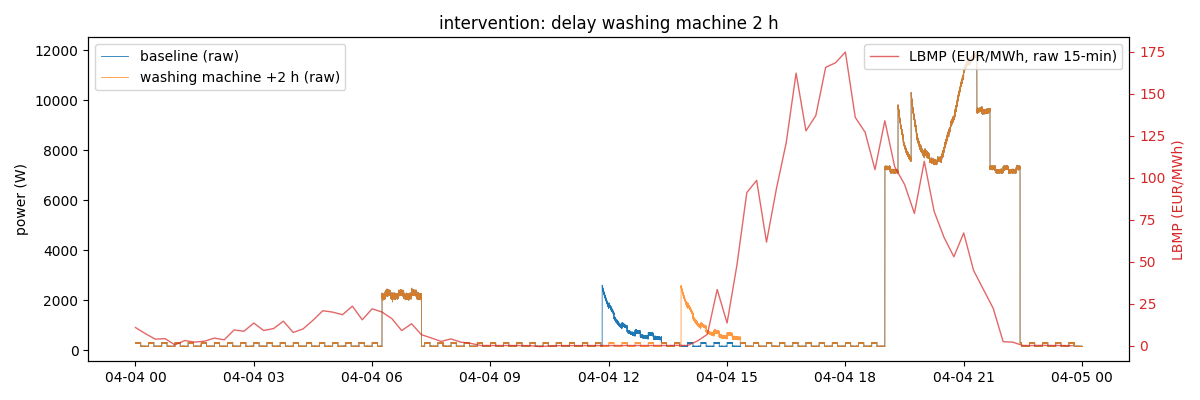

In [12]:
# Plot: baseline vs intervened aggregate, with realized prices on a twin axis.
# NOTE: all series are plotted at their original sampling cadence (no resampling here).
try:
    prices = load_price_history()
    day_px = prices[(prices['timestamp'] >= start) & (prices['timestamp'] < end)].sort_values('timestamp')
except FileNotFoundError:
    day_px = None
    print('No SMARD parquet — run scripts/fetch_smard_prices.py for the price overlay.')

baseline_raw = baseline.mains.sort_values('timestamp')
intervened_raw = intervened.mains.sort_values('timestamp')

fig, ax = plt.subplots(figsize=(12, 4))
line_base, = ax.plot(
    baseline_raw['timestamp'], baseline_raw['power_w'],
    lw=0.6, color='C0', label='baseline (raw)'
)
line_intv, = ax.plot(
    intervened_raw['timestamp'], intervened_raw['power_w'],
    lw=0.6, color='C1', alpha=0.8, label='washing machine +2 h (raw)'
)
ax.set_ylabel('power (W)')
ax.set_title('intervention: delay washing machine 2 h')

legend_handles = [line_base, line_intv]
legend_labels = [h.get_label() for h in legend_handles]

if day_px is not None and not day_px.empty:
    axp = ax.twinx()
    axp.plot(
        day_px['timestamp'], day_px['lbmp'], 
        color='C3', alpha=0.7, lw=1.0, label='LBMP (EUR/MWh, raw 15-min)'
    )
    axp.set_ylabel('LBMP (EUR/MWh)', color='C3')
    axp.tick_params(axis='y', colors='C3')
    axp.legend(loc='upper right')

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# Cost comparison: integrate each scenario's aggregate against the 15-min LBMP.
if day_px is not None and not day_px.empty:
    def integrate(mains_df, px_df):
        # Sum power × price per 15-min slot.
        mains = mains_df.copy()
        mains['slot'] = mains['timestamp'].dt.floor('15min')
        per_slot_w = mains.groupby('slot')['power_w'].mean().reset_index()
        merged = per_slot_w.merge(px_df.rename(columns={'timestamp': 'slot'}), on='slot', how='inner')
        # kW × $/MWh × h / 1000 → $
        cost = (merged['power_w'] / 1000.0 * merged['lbmp'] * 0.25 / 1000.0).sum()
        return float(cost)

    c_base = integrate(baseline.mains, day_px)
    c_int = integrate(intervened.mains, day_px)
    print(f'baseline    cost: ${c_base:.3f}')
    print(f'intervened  cost: ${c_int:.3f}')
    print(f'delta:           ${c_int - c_base:+.3f}  ({(c_int - c_base) / c_base * 100:+.1f}%)')

baseline    cost: $2.046
intervened  cost: $2.053
delta:           $+0.007  (+0.3%)
